# Clasificación en la práctica: KNN y Árbol de Decisión
## Dataset: Movie Classification (`Start_Tech_Oscar`)

**Objetivo:** predecir si una película gana el oscar (`Start_Tech_Oscar = 1`) o no (`= 0`).

**Plan:**
1. Cargar y explorar el dataset  
2. Preprocesamiento básico  
3. Modelo 1: K-Nearest Neighbors (KNN)  
4. Modelo 2: Árbol de Decisión  
5. Comparación final

---
## 0) Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

---
## 1) Cargar y explorar el dataset

In [2]:
df = pd.read_csv("Movie_classification.csv.xls")
print("Shape:", df.shape)
df.head()

Shape: (506, 19)


,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,3D_available,Time_taken,Twitter_hastags,Genre,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,YES,109.60,223.840,Thriller,23,494,48000,1
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,NO,146.64,243.456,Drama,42,462,43200,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,NO,147.88,2022.400,Comedy,38,458,69400,1
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,YES,185.36,225.344,Drama,45,472,66800,1
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,NO,176.48,225.792,Drama,55,395,72400,1


In [3]:
# Tipos de columnas y nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Marketing expense    506 non-null    float64
 1   Production expense   506 non-null    float64
 2   Multiplex coverage   506 non-null    float64
 3   Budget               506 non-null    float64
 4   Movie_length         506 non-null    float64
 5   Lead_ Actor_Rating   506 non-null    float64
 6   Lead_Actress_rating  506 non-null    float64
 7   Director_rating      506 non-null    float64
 8   Producer_rating      506 non-null    float64
 9   Critic_rating        506 non-null    float64
 10  Trailer_views        506 non-null    int64  
 11  3D_available         506 non-null    object 
 12  Time_taken           494 non-null    float64
 13  Twitter_hastags      506 non-null    float64
 14  Genre                506 non-null    object 
 15  Avg_age_actors       506 non-null    int

In [4]:
# Balance del target
print("Balance de clases:")
print(df["Start_Tech_Oscar"].value_counts())
print()
print(df["Start_Tech_Oscar"].value_counts(normalize=True).round(3))

Balance de clases:
Start_Tech_Oscar
1    276
0    230
Name: count, dtype: int64

Start_Tech_Oscar
1    0.545
0    0.455
Name: proportion, dtype: float64


In [5]:
# Estadísticas descriptivas
df.describe().round(2)

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,494.00,506.00,506.00,506.00,506.00,506.00
mean,92.27,77.27,0.45,34911.14,142.07,8.01,8.19,8.02,8.19,7.81,449860.72,157.39,260.83,39.18,545.04,45057.71,0.55
std,172.03,13.72,0.12,3903.04,28.15,1.05,1.05,1.06,1.05,0.66,68917.76,31.30,104.78,12.51,106.33,18364.35,0.50
min,20.13,55.92,0.13,19781.36,76.40,3.84,4.04,3.84,4.03,6.60,212912.00,0.00,201.15,3.00,333.00,10000.00,0.00
25%,21.64,65.38,0.38,32693.95,118.52,7.32,7.50,7.30,7.51,7.20,409128.00,132.30,223.80,28.00,465.00,34050.00,0.00
50%,25.13,74.38,0.46,34488.22,151.00,8.31,8.50,8.31,8.46,7.96,462460.00,160.00,254.40,39.00,535.50,42400.00,1.00
75%,93.54,91.20,0.55,36793.54,167.58,8.86,9.03,8.88,9.03,8.26,500247.50,181.89,283.42,50.00,614.75,50000.00,1.00
max,1799.52,110.48,0.62,48772.90,173.50,9.44,9.54,9.43,9.64,9.40,567784.00,217.52,2022.40,60.00,868.00,100000.00,1.00


---
## 2) Preprocesamiento

Pasos necesarios:
- Separar **features (X)** y **target (y)**
- Manejar **valores nulos** (`Time_taken` tiene 12 filas con NaN)
- Convertir variables **categóricas** (`Genre`, `3D_available`) a numéricas
- Hacer el **split** train / test
- **Escalar** (obligatorio para KNN; opcional para árbol)

In [6]:
# 2.1 Imputar nulos en Time_taken con la mediana
df["Time_taken"] = df["Time_taken"].fillna(df["Time_taken"].median())

print("Nulos restantes:", df.isnull().sum().sum())

Nulos restantes: 0


In [7]:
# 2.2 Codificar categóricas
# 3D_available: YES=1, NO=0
df["3D_available"] = df["3D_available"].map({"YES": 1, "NO": 0})

# Genre: one-hot encoding
df = pd.get_dummies(df, columns=["Genre"], drop_first=True)

print("Columnas nuevas con dummies:", [c for c in df.columns if c.startswith("Genre")])
df.head(3)

Columnas nuevas con dummies: ['Genre_Comedy', 'Genre_Drama', 'Genre_Thriller']


,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,...,3D_available,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar,Genre_Comedy,Genre_Drama,Genre_Thriller
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,...,1,109.60,223.840,23,494,48000,1,False,False,True
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,...,0,146.64,243.456,42,462,43200,0,False,True,False
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,...,0,147.88,2022.400,38,458,69400,1,True,False,False


In [8]:
# 2.3 Separar X e y
TARGET = "Start_Tech_Oscar"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Features:", list(X.columns))
print("Shape X:", X.shape, "| Shape y:", y.shape)

Features: ['Marketing expense', 'Production expense', 'Multiplex coverage', 'Budget', 'Movie_length', 'Lead_ Actor_Rating', 'Lead_Actress_rating', 'Director_rating', 'Producer_rating', 'Critic_rating', 'Trailer_views', '3D_available', 'Time_taken', 'Twitter_hastags', 'Avg_age_actors', 'Num_multiplex', 'Collection', 'Genre_Comedy', 'Genre_Drama', 'Genre_Thriller']
Shape X: (506, 20) | Shape y: (506,)


In [9]:
# 2.4 Train / Test split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (404, 20) | Test: (102, 20)


---
## 3) Baseline (referencia mínima)

Antes de cualquier modelo, establecemos un **baseline** que simplemente predice la clase mayoritaria.  
Cualquier modelo decente debe superar esto.

In [10]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
pred_base = baseline.predict(X_test)

print(f"Baseline accuracy : {accuracy_score(y_test, pred_base):.3f}")
print(f"Baseline F1       : {f1_score(y_test, pred_base, zero_division=0):.3f}")

Baseline accuracy : 0.549
Baseline F1       : 0.709


---
## 4) Modelo 1: K-Nearest Neighbors (KNN)

KNN clasifica un punto nuevo según la **votación de sus $k$ vecinos más cercanos**.  
Requiere **escalado** porque usa distancias.

In [11]:
# 4.1 Entrenar KNN con k=5 (valor por defecto)
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn",    KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

print(f"KNN (k=5) accuracy : {accuracy_score(y_test, pred_knn):.3f}")
print(f"KNN (k=5) F1       : {f1_score(y_test, pred_knn):.3f}")

KNN (k=5) accuracy : 0.627
KNN (k=5) F1       : 0.667


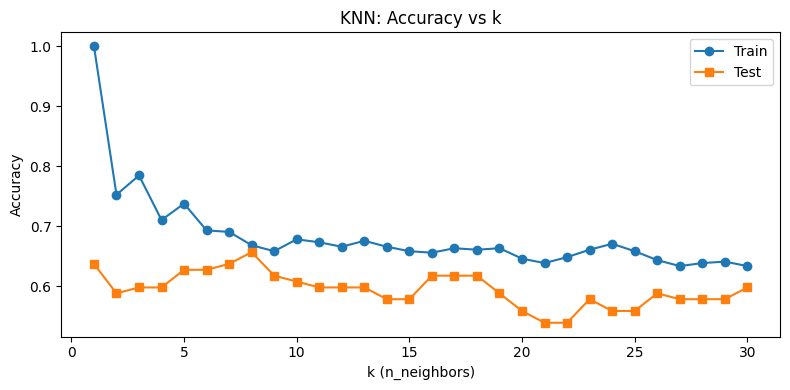

Mejor k en test: 8 — Accuracy: 0.657


In [12]:
# 4.2 ¿Cómo cambia el accuracy con distintos valores de k?
k_values = list(range(1, 31))
acc_train_knn = []
acc_test_knn  = []

for k in k_values:
    m = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))])
    m.fit(X_train, y_train)
    acc_train_knn.append(accuracy_score(y_train, m.predict(X_train)))
    acc_test_knn.append(accuracy_score(y_test,  m.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(k_values, acc_train_knn, marker="o", label="Train")
plt.plot(k_values, acc_test_knn,  marker="s", label="Test")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN: Accuracy vs k")
plt.legend()
plt.tight_layout()
plt.show()

best_k   = k_values[int(np.argmax(acc_test_knn))]
best_acc = max(acc_test_knn)
print(f"Mejor k en test: {best_k} — Accuracy: {best_acc:.3f}")

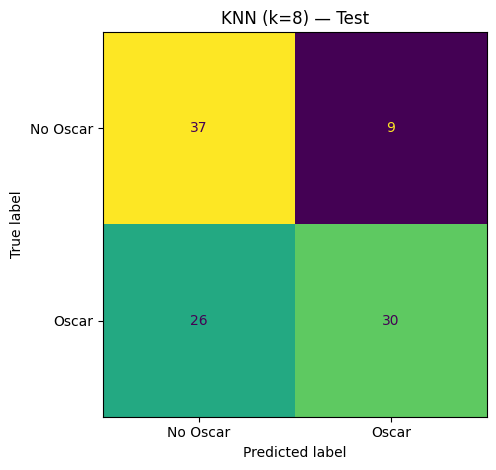

Accuracy : 0.657
F1       : 0.632


In [13]:
# 4.3 Entrenar KNN con el mejor k y ver la matriz de confusión
knn_best = Pipeline([
    ("scaler", StandardScaler()),
    ("knn",    KNeighborsClassifier(n_neighbors=best_k))
])
knn_best.fit(X_train, y_train)
pred_knn_best = knn_best.predict(X_test)

cm_knn = confusion_matrix(y_test, pred_knn_best)
disp   = ConfusionMatrixDisplay(cm_knn, display_labels=["No Oscar", "Oscar"])
disp.plot(colorbar=False)
plt.title(f"KNN (k={best_k}) — Test")
plt.tight_layout()
plt.show()

print(f"Accuracy : {accuracy_score(y_test, pred_knn_best):.3f}")
print(f"F1       : {f1_score(y_test, pred_knn_best):.3f}")

---
## 5) Modelo 2: Árbol de Decisión

El árbol divide el espacio de features con **reglas** del tipo `x1 < 3.2`.  
No necesita escalado.  
Sin control, tiende a sobreajustar → usamos `max_depth` para regularlo.

In [14]:
# 5.1 Árbol sin restricciones — ¿sobreajusta?
dt_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_full.fit(X_train, y_train)

print(f"Profundidad: {dt_full.get_depth()} | Hojas: {dt_full.get_n_leaves()}")
print(f"Accuracy train : {accuracy_score(y_train, dt_full.predict(X_train)):.3f}")
print(f"Accuracy test  : {accuracy_score(y_test,  dt_full.predict(X_test)):.3f}")

Profundidad: 14 | Hojas: 76
Accuracy train : 1.000
Accuracy test  : 0.549


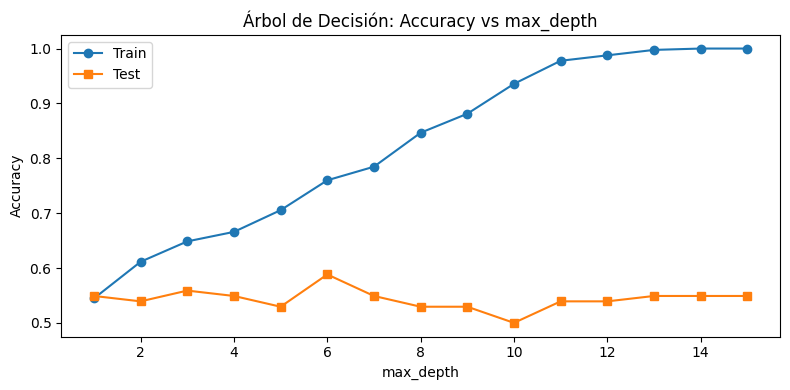

Mejor max_depth en test: 6 — Accuracy: 0.588


In [15]:
# 5.2 Curva de sobreajuste: train vs test según max_depth
depths = list(range(1, 16))
acc_train_dt = []
acc_test_dt  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    acc_train_dt.append(accuracy_score(y_train, dt.predict(X_train)))
    acc_test_dt.append(accuracy_score(y_test,  dt.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(depths, acc_train_dt, marker="o", label="Train")
plt.plot(depths, acc_test_dt,  marker="s", label="Test")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Árbol de Decisión: Accuracy vs max_depth")
plt.legend()
plt.tight_layout()
plt.show()

best_depth = depths[int(np.argmax(acc_test_dt))]
print(f"Mejor max_depth en test: {best_depth} — Accuracy: {max(acc_test_dt):.3f}")

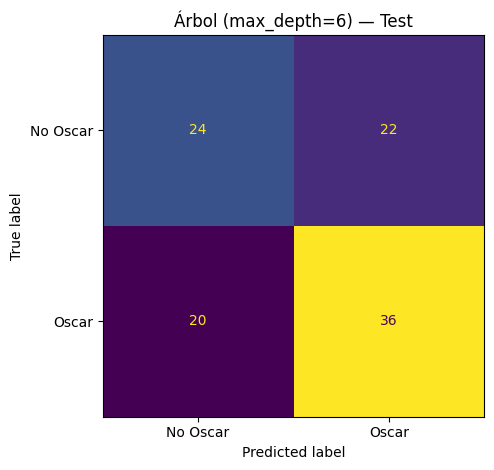

Accuracy : 0.588
F1       : 0.632


In [16]:
# 5.3 Árbol con mejor max_depth
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_best.fit(X_train, y_train)
pred_dt = dt_best.predict(X_test)

cm_dt = confusion_matrix(y_test, pred_dt)
disp  = ConfusionMatrixDisplay(cm_dt, display_labels=["No Oscar", "Oscar"])
disp.plot(colorbar=False)
plt.title(f"Árbol (max_depth={best_depth}) — Test")
plt.tight_layout()
plt.show()

print(f"Accuracy : {accuracy_score(y_test, pred_dt):.3f}")
print(f"F1       : {f1_score(y_test, pred_dt):.3f}")

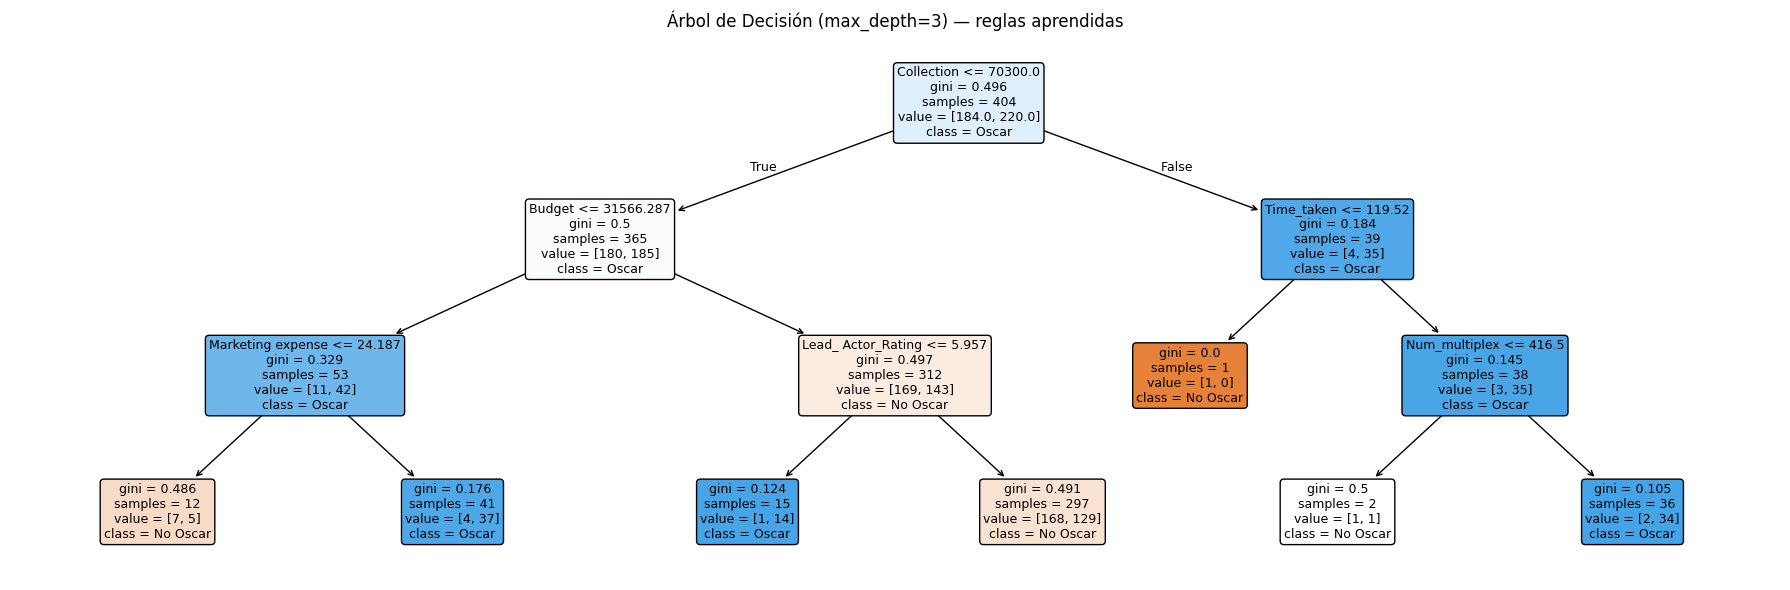

In [17]:
# 5.4 Visualizar el árbol (limitamos a depth=3 para que sea legible)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt_viz.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    dt_viz,
    feature_names=list(X.columns),
    class_names=["No Oscar", "Oscar"],
    filled=True, rounded=True,
    ax=ax, fontsize=9
)
ax.set_title("Árbol de Decisión (max_depth=3) — reglas aprendidas")
plt.tight_layout()
plt.show()

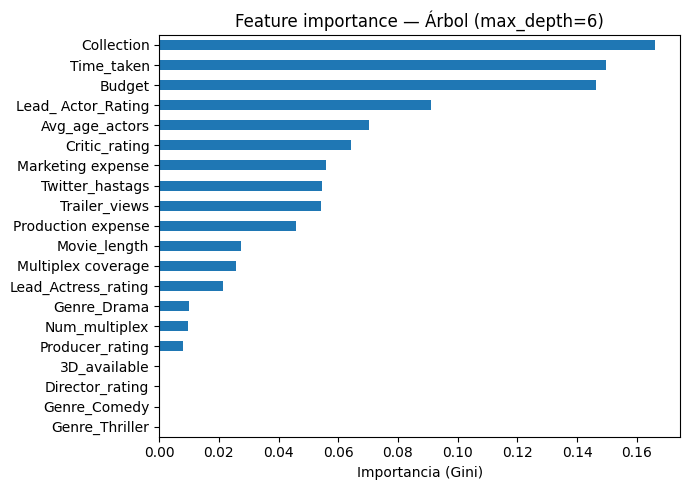

In [18]:
# 5.5 Feature importance del árbol
importances = pd.Series(dt_best.feature_importances_, index=X.columns)\
                .sort_values(ascending=True)

plt.figure(figsize=(7, 5))
importances.plot(kind="barh")
plt.xlabel("Importancia (Gini)")
plt.title(f"Feature importance — Árbol (max_depth={best_depth})")
plt.tight_layout()
plt.show()

---
## 6) Comparación final

In [19]:
results = pd.DataFrame([
    {
        "Modelo": "Baseline (most frequent)",
        "Accuracy": accuracy_score(y_test, pred_base),
        "F1": f1_score(y_test, pred_base, zero_division=0)
    },
    {
        "Modelo": f"KNN (k={best_k})",
        "Accuracy": accuracy_score(y_test, pred_knn_best),
        "F1": f1_score(y_test, pred_knn_best)
    },
    {
        "Modelo": f"Árbol de Decisión (max_depth={best_depth})",
        "Accuracy": accuracy_score(y_test, pred_dt),
        "F1": f1_score(y_test, pred_dt)
    },
]).set_index("Modelo").round(3)

results

,Accuracy,F1
Modelo,,
Baseline (most frequent),0.549,0.709
KNN (k=8),0.657,0.632
Árbol de Decisión (max_depth=6),0.588,0.632


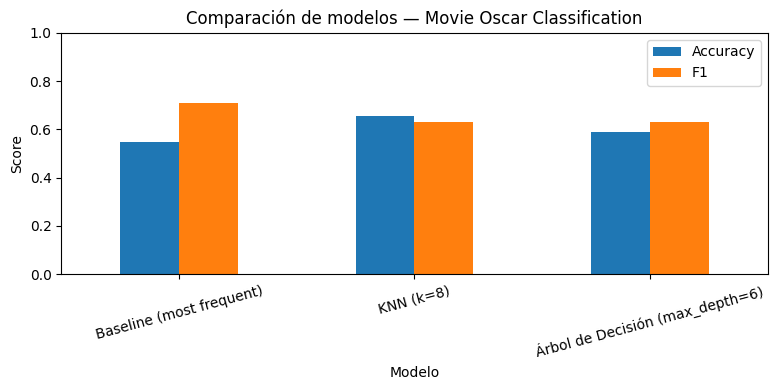

In [20]:
# Gráfico de barras comparativo
results.plot(kind="bar", figsize=(8, 4), ylim=(0, 1), rot=15)
plt.ylabel("Score")
plt.title("Comparación de modelos — Movie Oscar Classification")
plt.tight_layout()
plt.show()